# DES-UCB: Drift-triggered Evidence-Switching UCB

Research prototype for *"Drift-triggered evidence switching suppresses stale priors in cold-start
interactive recommendation"*. One notebook + one tested helper module (`des_ucb_core.py`).
Everything below is produced by executing this notebook top-to-bottom; nothing is pre-filled.

## 1. Method — what is borrowed vs. what is new

**Borrowed (cited, not claimed):**

* **SW-UCB** — sliding-window LinUCB with the forgetting principle; optimal dynamic regret when the
  variation budget is known (Garivier & Moulines 2011; Cheung, Simchi-Levi & Zhu 2019).
* **Bandit-over-Bandit (BOB)** — EXP3 over candidate window lengths, updated once per block of
  length `H`, for an *unknown* variation budget (Cheung, Simchi-Levi & Zhu 2019). Baseline **B4**.
* **Change-point-triggered restarts** — detect a shift in the residual stream and restart the
  estimator (e.g. Page–Hinkley; ADWIN of Bifet & Gavaldà 2007). Baseline **B6** is this route.

**New (the claim under test):** a cold-start user comes with two *evidence sources*

* **P** (prior-driven): a ridge fit on pre-interaction rows `D_prior` (cohort / demographic /
  the user's own stale history), frozen unless `alpha_prior_mix > 0`;
* **F** (feedback-driven): a sliding-window ridge on *this user's* live rows;

and DES-UCB adds

1. a **meta-controller** (`EvidenceSwitch`, EXP3 by default) that each round chooses which source
   to *condition the UCB on*, credited with the realised **generalisation gain** — the held-out
   squared-error reduction of the chosen source relative to the alternative on the row just
   observed (scale-free, clipped to `[-G, G]`, rescaled to `[0,1]`);
2. a **drift-triggered suppression step** — when a Page–Hinkley test on the active source's
   squared residual fires: halve the window and purge older rows, *reset the credit of P*, and
   force **F-only for a burn-in of `B` rounds** — instead of passive decay of the prior.

The window length itself is chosen by BOB (borrowed). Ablations A1–A7 remove each new piece.

### Theory note (proof obligation — appendix, **not yet a result**)

Target theorem **T1**:

> `R_T(DES-UCB) <= R_T(SW-UCB/BOB) + O(sqrt(T)) [EXP3 switching over 2 sources with bounded clipped gain] + N_fired * B * Delta_max [burn-in cost].`

This would show that switching and suppression cost at most lower-order terms on top of the
borrowed SW-UCB/BOB guarantee. It does **not** show that switching or suppression *help* — that
would be a separate statement (T2), and here it is tested only empirically (section 13).
On real data none of this applies: `offline_regret` (best *rated* candidate) is not dynamic regret.

In [1]:
import copy, json, math, time, warnings, os
from pathlib import Path
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
import des_ucb_core as C

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", module="urllib3")
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
RES = C.RESULTS_DIR; RES.mkdir(exist_ok=True)
T_START = time.time()

def show(df, floatfmt=".3f"):
    print(df.to_markdown(floatfmt=floatfmt))

def savefig(name):
    plt.tight_layout(); plt.savefig(RES / f"{name}.png", dpi=110); plt.show()

CFG = C.load_config()
print(json.dumps({k: v for k, v in CFG.items() if k != "experiments"}, indent=1, default=str)[:1500])

{
 "seed": 0,
 "n_seeds": 5,
 "n_users": 100,
 "T": 2000,
 "d": 16,
 "N_items": 500,
 "K_cand": 20,
 "lam": 1.0,
 "beta": 0.5,
 "S": 5.0,
 "switch": {
  "kind": "exp3",
  "gamma": 0.1,
  "c": 1.0,
  "G": 1.0
 },
 "alpha_prior_mix": 0.0,
 "w_0": 400,
 "w_min": 50,
 "candidate_windows": [
  50,
  100,
  200,
  400,
  800
 ],
 "H": 100,
 "bob_gamma": 0.1,
 "burn_in_B": 30,
 "reward_range": [
  -2.0,
  2.0
 ],
 "detector": {
  "type": "page_hinkley",
  "delta": 0.005,
  "lam_threshold": 1.0,
  "alpha_forget": 0.999,
  "min_instances": 30
 },
 "prior": {
  "K_cohorts": 8,
  "n_prior_rows": 200,
  "sigma_prior": 0.1,
  "p_mismatch": 0.0,
  "prior_from_pre_drift": true
 },
 "drift": {
  "type": "abrupt",
  "change_points": [
   600,
   1300
  ],
  "magnitude": 1.0,
  "sigma_reward": 0.1,
  "reward_model": "gaussian",
  "gradual_G": 300,
  "recurring_P": 500,
  "incremental_eps": 0.01,
  "sinusoidal_period": 500
 },
 "baselines": {
  "sw_window": 400,
  "discount_gamma": 0.995
 },
 "datasets":

## 2. Synthetic environment — the only place *dynamic regret* is defined

`SyntheticEnv`: `N_items` unit-norm contexts, `K_cohorts` prototypes, hidden user parameter
`theta_t`, reward `r = x^T theta_t + N(0, sigma^2)` (or Bernoulli(sigmoid)), oracle
`max_a x_a^T theta_t` over the `K_cand` candidates. Drift types: none / abrupt / gradual /
recurring / incremental / sinusoidal; `drift.magnitude = ||theta_1 - theta_0||`.

Three **staleness knobs** (ablated one at a time in section 9):

* `p_mismatch` — prior drawn from the *wrong* cohort (misspecified prior);
* `prior_from_pre_drift` — prior built from `theta_0`, user drifts to `theta_1` (**stale prior**:
  the case the title claims; default `true`);
* `sigma_prior` — weak-but-unbiased prior (suppression should *not* help here).

Sanity plot: `||theta_t - theta_0||` per drift type for one user.

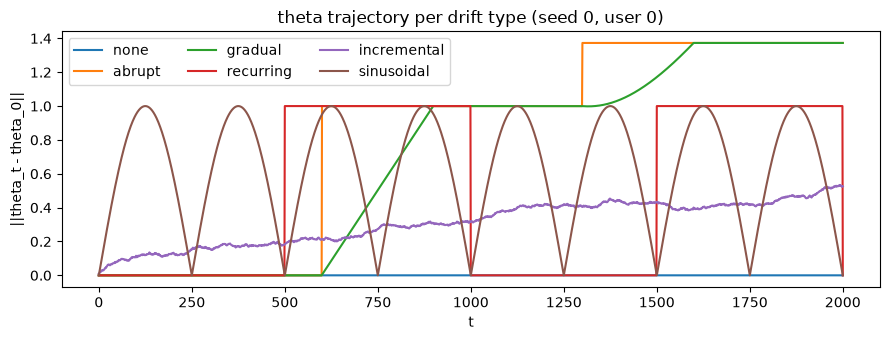

d = 16 | T = 2000 | D_prior rows = 200 | regret_kind = dynamic


In [2]:
DRIFTS = ["none", "abrupt", "gradual", "recurring", "incremental", "sinusoidal"]
fig, ax = plt.subplots(1, 1, figsize=(9, 3.5))
for dt in DRIFTS:
    cfg_dt = C.load_config(f"drift_{dt}")
    env = C.SyntheticEnv(cfg_dt, seed=0, user=0)
    dev = np.linalg.norm(env.thetas - env.theta0, axis=1)
    ax.plot(dev, label=dt)
ax.set_xlabel("t"); ax.set_ylabel("||theta_t - theta_0||"); ax.legend(ncol=3); ax.set_title("theta trajectory per drift type (seed 0, user 0)")
savefig("theta_trajectories")
env = C.SyntheticEnv(CFG, 0, 0)
print("d =", env.d, "| T =", env.T, "| D_prior rows =", len(env.D_prior[1]), "| regret_kind =", env.regret_kind)

## 3. Real-data loaders (same `Env` interface; all optional via `cfg.datasets`)

**Rule for real data:** the environment can only reveal rewards of items the user actually rated
or saw. Hence (a) candidates = `K_cand` rated-and-not-yet-shown items (or the actual impression
list for MIND); (b) "oracle" = best *available* reward in that candidate set; (c) the resulting
quantity is `offline_regret`, never dynamic regret; (d) primary metrics are cumulative
precision@T / recall@T (hit = rating ≥ 4 or click), following the ICF/NICF protocol.

* **ML-1M** (required; ML-100K as smoke switch): 18 genre one-hot + SVD item embedding fit on
  train-user ratings (user-disjoint 85/5/10), users ≥ 100 ratings. Protocol **A** cold start,
  **B** induced drift (chronological half-split; prior = the user's own early half), **C** stale
  prior from a *different demographic cohort* w.p. `p_mismatch`.
* **MIND-small** (required if network permits): TF-IDF(title)→SVD + category one-hot; reward = click;
  candidates = actual impression list; chronological; detector firings vs calendar-day boundaries.
  The official Azure blob refuses anonymous downloads (HTTP 409) so the raw TSVs come from a public
  Hugging Face mirror.
* **Netflix / Yahoo R6 / KuaiRand / Amazon-2023**: optional, gated on local paths/flags. R6 and
  KuaiRand use the **replay estimator** (`replay_reward` — the only real-data metric that may be
  called unbiased). Amazon is only ever a cross-category `D_prior` (review time ≠ purchase time).

Loaders cache parquet under `data/` and print a stats table. Here we only *load* and describe; the
experiments are in section 10.

In [3]:
DS = CFG["datasets"]; REAL = {}
def try_load(name, fn):
    try:
        t0 = time.time(); REAL[name] = fn(); print(f"[{name}] ready in {time.time()-t0:.1f}s")
    except Exception as e:  # network / path problems must not stop the notebook
        print(f"[{name}] SKIPPED: {type(e).__name__}: {str(e)[:200]}")

if DS.get("movielens_100k_smoke"):
    CFG_ML100K = C.load_config("movielens_100k")
    try_load("ml-100k", lambda: C.prepare_movielens(CFG_ML100K, "ml-100k"))
if DS.get("movielens_1m"):
    CFG_ML1M = C.load_config("movielens_1m")
    try_load("ml-1m", lambda: C.prepare_movielens(CFG_ML1M, "ml-1m"))
if DS.get("mind_small"):
    CFG_MIND = C.load_config("mind_small")
    try_load("mind", lambda: C.prepare_mind(CFG_MIND))
if DS.get("netflix") and DS.get("netflix_path"):
    CFG_NF = C.load_config("netflix")
    try_load("netflix", lambda: C.load_netflix(DS["netflix_path"], CFG_NF))
if DS.get("yahoo_r6_path"):
    try_load("yahoo_r6", lambda: C.load_yahoo_r6(DS["yahoo_r6_path"]))
if DS.get("kuairand") and DS.get("kuairand_path"):
    try_load("kuairand", lambda: C.load_kuairand_random(DS["kuairand_path"], d=CFG["d"]))
if DS.get("amazon_2023"):
    print("WARNING: Amazon Reviews 2023 review time != purchase time; used ONLY to build a cross-category D_prior, never for drift claims.")
    try_load("amazon_prior", lambda: C.amazon_cross_category_prior(C.load_config("amazon_2023"), d=CFG["d"]))
for k, v in REAL.items():
    if isinstance(v, C.RatedDataset):
        print(f"{k}: d={v.d}, test users={len(v.test_users)}, cohorts={len(v.cohort_rows)}")

| dataset   |   #users |   #items |   #interactions | span                     |
|:----------|---------:|---------:|----------------:|:-------------------------|
| ml-100k   |      943 |     1682 |          100000 | 1997-09-20 .. 1998-04-22 |
[ml-100k] ready in 0.7s
| dataset   |   #users |   #items |   #interactions | span                     |
|:----------|---------:|---------:|----------------:|:-------------------------|
| ml-1m     |     6040 |     3706 |         1000209 | 2000-04-25 .. 2003-02-28 |


[ml-1m] ready in 0.6s


| dataset                  |   #users |   #items |   #interactions | span                     |
|:-------------------------|---------:|---------:|----------------:|:-------------------------|
| MIND-small (impressions) |    50000 |     5910 |          156965 | 2019-11-09 .. 2019-11-14 |


[mind] ready in 13.2s
ml-100k: d=34, test users=37, cohorts=75
ml-1m: d=34, test users=295, cohorts=14
mind: d=49, test users=94, cohorts=6


## 4. Runner

`C.run(env_factory, agents, cfg, n_seeds, n_users, exp_name)` loops seeds × users × agents × rounds
(multiprocessing over (seed, user) jobs), and logs per round
`seed, user, t, agent, reward, oracle_or_best_available, regret_kind ∈ {dynamic, offline, replay},
regret, source, window, drift_fired, true_change`; the log is saved to `results/<exp>.parquet`.
Every agent of a job sees the *identical* environment (`env.reset()` between agents; noise is
pre-drawn), so comparisons are paired.

In [4]:
def synth_factory(cfg):
    return lambda seed, user: C.SyntheticEnv(cfg, seed, user)

def run_synth(cfg, agents, size, exp_name, **over):
    ex = dict(cfg["experiments"][size]); ex.update(over)
    T = ex.get("T", cfg["T"])
    o = {"T": T}
    if "change_points" in ex:
        o["drift"] = {"change_points": ex["change_points"]}
    cfg2 = C._deep_update(cfg, o)
    return C.run(synth_factory(cfg2), agents, cfg2, n_seeds=ex["n_seeds"], n_users=ex["n_users"], exp_name=exp_name), cfg2

smoke, _ = run_synth(CFG, ["DES-UCB", "B2"], "pilot", None, n_seeds=1, n_users=2, T=200)
print(smoke.head(3).to_string()); print(smoke.dtypes.to_dict())

run:   0%|          | 0/2 [00:00<?, ?it/s]

   seed  user  t    agent    reward  oracle_or_best_available regret_kind    regret source  window  drift_fired  true_change
0     0     1  0  DES-UCB  0.543212                  0.586961     dynamic  0.000000      P     400        False        False
1     0     1  1  DES-UCB  0.359428                  0.354790     dynamic  0.021558      P     400        False        False
2     0     1  2  DES-UCB  0.231309                  0.273939     dynamic  0.028374      P     400        False        False
{'seed': dtype('int32'), 'user': dtype('int32'), 't': dtype('int32'), 'agent': CategoricalDtype(categories=['B2', 'DES-UCB'], ordered=False, categories_dtype=str), 'reward': dtype('float64'), 'oracle_or_best_available': dtype('float64'), 'regret_kind': CategoricalDtype(categories=['dynamic'], ordered=False, categories_dtype=str), 'regret': dtype('float64'), 'source': CategoricalDtype(categories=['F', 'P', 'P+F'], ordered=False, categories_dtype=str), 'window': dtype('int32'), 'drift_fired': dtyp

## 5. Metrics — two namespaces, never mixed

**SYNTHETIC (dynamic):** `dynamic_regret = Σ_t (oracle_t − r_t)`; per-round curve; recovery time
(rounds until the 20-round moving-average regret is back within 10% of the pre-drift level);
`stale_evidence_ratio` (post-change rounds with `source == "P"`); detection delay and false alarms;
cold-start mean reward at t = 10/20/50; log-log regret slope vs T.

**REAL (offline / replay):** `cum_precision@{5,10,20,40}`, `cum_recall@T`, `offline_regret`
(rated-candidate oracle), `replay_reward` where a random-logging slice exists;
`stale_evidence_ratio` around the induced split.

All: mean ± std over (seed, user) units; **paired bootstrap 95% CI** for method differences
(`C.summarize_pairs`). Every metric function asserts the namespace of its input
(`C._assert_kind`) — mixing raises.

In [5]:
show(C.dynamic_regret(smoke))
try:
    C.offline_regret(smoke)
except ValueError as e:
    print("namespace guard OK ->", e)

| agent   |   dynamic_regret_mean |   dynamic_regret_std |   n_units |
|:--------|----------------------:|---------------------:|----------:|
| B2      |                 0.306 |                0.029 |     2.000 |
| DES-UCB |                 1.517 |                0.501 |     2.000 |
namespace guard OK -> metric namespace mismatch: expected only 'offline', log contains ['dynamic']


## 6. Pilot (runs first, < 5 min)

1 seed, 20 users, T = 1000, abrupt drift at t = 500, `prior_from_pre_drift = true`,
`p_mismatch = 0`; agents DES-UCB, A2 (no suppression), B4 (BOB). Prints detection delay, dynamic
regret, stale-evidence ratio and which decision-table branch (section 13) applies *so far*.
Everything below runs regardless; the pilot verdict is recorded.

**Recorded pilot observation (design decision):** with the spec's `lam_threshold = 50` the Page–Hinkley
test never fired on squared residuals of rewards with `sigma_reward = 0.1` (0/20 changes detected in
the first pilot run) — the decision table's "DETECTION FAILURE: tune PH threshold, retest" branch.
`configs/default.yaml` therefore ships `lam_threshold = 1.0` (20/20 detected, mean delay < `burn_in_B`,
0 false alarms on `drift=none` in the retest). The cell below re-checks this on the current run.

In [6]:
PILOT_AGENTS = ["DES-UCB", "A2", "B4"]
pilot_cfg = C.load_config("drift_abrupt", overrides={"prior": {"prior_from_pre_drift": True, "p_mismatch": 0.0}})
pilot, pilot_cfg2 = run_synth(pilot_cfg, PILOT_AGENTS, "pilot", "pilot")
pilot_reg = C.dynamic_regret(pilot); pilot_det = C.detection_stats(pilot); pilot_stale = C.stale_evidence_ratio(pilot)
print("dynamic regret (mean over units)"); show(pilot_reg)
print("\ndetection"); show(pilot_det)
print("\nstale evidence ratio (post-change rounds on P)"); show(pilot_stale.to_frame())
pilot_reg.to_csv(RES / "pilot_regret.csv"); pilot_det.to_csv(RES / "pilot_detection.csv")

pilot_delay = float(pilot_det.loc["DES-UCB", "mean_delay"])
pilot_pairs = C.summarize_pairs(C.per_unit(pilot), [("DES-UCB", "A2"), ("DES-UCB", "B4")])
show(pilot_pairs)
PILOT_VERDICT = {
    "detector_mean_delay": pilot_delay, "burn_in_B": pilot_cfg2["burn_in_B"],
    "detected_fraction": float(pilot_det.loc["DES-UCB", "detected"] / max(1, pilot_det.loc["DES-UCB", "n_changes"])),
    "branch": ("DETECTION FAILURE: tune PH threshold, retest" if (math.isnan(pilot_delay) or pilot_delay > pilot_cfg2["burn_in_B"])
               else "detector OK (delay <= B); suppression verdict deferred to section 13 (needs 5 seeds x 100 users)"),
    "DES_minus_A2_regret": float(pilot_pairs.iloc[0]["mean_diff(A-B)"]), "DES_minus_B4_regret": float(pilot_pairs.iloc[1]["mean_diff(A-B)"]),
}
print("\nPILOT VERDICT:", json.dumps(PILOT_VERDICT, indent=1))
(RES / "pilot_verdict.json").write_text(json.dumps(PILOT_VERDICT, indent=1))

pilot:   0%|          | 0/20 [00:00<?, ?it/s]

dynamic regret (mean over units)
| agent   |   dynamic_regret_mean |   dynamic_regret_std |   n_units |
|:--------|----------------------:|---------------------:|----------:|
| A2      |                35.112 |               13.506 |    20.000 |
| B4      |                28.972 |               10.699 |    20.000 |
| DES-UCB |                22.660 |                4.758 |    20.000 |

detection
| agent   |   n_changes |   detected |   missed |   mean_delay |   median_delay |   false_alarms_per_unit |   total_firings |
|:--------|------------:|-----------:|---------:|-------------:|---------------:|------------------------:|----------------:|
| A2      |      20.000 |     20.000 |    0.000 |       25.050 |         22.000 |                   0.100 |          25.000 |
| B4      |      20.000 |      0.000 |   20.000 |      nan     |        nan     |                   0.000 |           0.000 |
| DES-UCB |      20.000 |     20.000 |    0.000 |       21.100 |         20.000 |                

277

## 7. Synthetic full grid — all drift types × all baselines + DES-UCB

For each drift type (`configs/drift_*.yaml`) we run B1–B9 and DES-UCB and report mean ± std
dynamic regret, recovery time and cold-start reward. Sizes come from `experiments.grid` in
`default.yaml` (scaled to fit the 30-minute budget; the claim registry re-runs the claim-relevant
cells at full size).

In [7]:
GRID_AGENTS = ["DES-UCB"] + C.ALL_BASELINES
grid_logs, grid_rows = {}, []
for dt in DRIFTS:
    cfg_dt = C.load_config(f"drift_{dt}")
    df, _ = run_synth(cfg_dt, GRID_AGENTS, "grid", f"grid_{dt}")
    grid_logs[dt] = df
    r = C.dynamic_regret(df); cs = C.cold_start_reward(df)
    rec = C.recovery_time(df) if dt in ("abrupt", "gradual", "recurring") else None
    for a in r.index:
        grid_rows.append({"drift": dt, "agent": a, "dyn_regret_mean": r.loc[a, "dynamic_regret_mean"],
                          "dyn_regret_std": r.loc[a, "dynamic_regret_std"],
                          "recovery_time": (rec.get(a, np.nan) if rec is not None else np.nan),
                          **cs.loc[a].to_dict()})
GRID = pd.DataFrame(grid_rows); GRID.to_csv(RES / "grid_summary.csv", index=False)
show(GRID.pivot(index="agent", columns="drift", values="dyn_regret_mean").loc[GRID_AGENTS], ".2f")
print("\nrank of DES-UCB per drift type (1 = lowest regret, B9 oracle excluded):")
noorc = GRID[GRID.agent != "B9"]
print({dt: int(g.set_index("agent")["dyn_regret_mean"].rank()["DES-UCB"]) for dt, g in noorc.groupby("drift")})

grid_none:   0%|          | 0/60 [00:00<?, ?it/s]

grid_abrupt:   0%|          | 0/60 [00:00<?, ?it/s]

grid_gradual:   0%|          | 0/60 [00:00<?, ?it/s]

grid_recurring:   0%|          | 0/60 [00:00<?, ?it/s]

grid_incremental:   0%|          | 0/60 [00:00<?, ?it/s]

grid_sinusoidal:   0%|          | 0/60 [00:00<?, ?it/s]

| agent   |   abrupt |   gradual |   incremental |   none |   recurring |   sinusoidal |
|:--------|---------:|----------:|--------------:|-------:|------------:|-------------:|
| DES-UCB |    50.74 |     41.02 |         22.27 |  11.28 |       55.98 |       146.36 |
| B1      |   130.86 |    117.02 |         21.64 |   8.01 |       91.79 |       198.59 |
| B2      |   145.71 |    128.90 |         18.38 |   1.63 |       96.35 |       187.47 |
| B3      |    49.32 |     34.48 |         15.31 |  10.37 |       79.76 |       272.59 |
| B4      |    49.41 |     37.50 |         23.87 |  20.02 |       66.90 |       166.23 |
| B5      |    40.87 |     29.68 |         14.95 |  11.09 |       57.33 |       168.33 |
| B6      |    30.69 |     33.85 |         23.07 |   8.01 |       39.63 |        98.30 |
| B7      |   370.14 |    304.90 |         47.58 |   6.63 |      188.98 |       188.73 |
| B8      |  1248.87 |   1186.30 |        942.37 | 912.45 |     1073.99 |      1095.09 |
| B9      |     0.00 

## 8. Ablations — on abrupt and gradual drift

A1 `no_switch` (fixed P→F schedule), A2 `no_suppression` (detector fires, nothing happens),
A3 `no_detector`, A4 `no_bob` (fixed `w_0`), A5 `decay_instead` (halve the prior's weight on each
firing instead of purge/reset/burn-in), A6 `uncertainty_gain` (credit by confidence-width
reduction instead of realised error reduction), A7 `switch_kind = ucb1`.

In [8]:
ABL_AGENTS = ["DES-UCB"] + C.ALL_ABLATIONS
abl_logs, abl_rows = {}, []
for dt in ["abrupt", "gradual"]:
    df, _ = run_synth(C.load_config(f"drift_{dt}"), ABL_AGENTS, "ablation", f"ablation_{dt}")
    abl_logs[dt] = df
    r = C.dynamic_regret(df); st = C.stale_evidence_ratio(df); det = C.detection_stats(df)
    pairs = C.summarize_pairs(C.per_unit(df), [("DES-UCB", a) for a in C.ALL_ABLATIONS]).set_index("B")
    for a in r.index:
        abl_rows.append({"drift": dt, "agent": a, "label": C.AGENT_LABELS[a], "dyn_regret_mean": r.loc[a, "dynamic_regret_mean"],
                         "dyn_regret_std": r.loc[a, "dynamic_regret_std"], "stale_ratio": st.get(a, np.nan),
                         "mean_delay": det.loc[a, "mean_delay"], "total_firings": det.loc[a, "total_firings"],
                         "DES_minus_this": (pairs.loc[a, "mean_diff(A-B)"] if a in pairs.index else 0.0),
                         "ci_lo": (pairs.loc[a, "ci_lo"] if a in pairs.index else 0.0),
                         "ci_hi": (pairs.loc[a, "ci_hi"] if a in pairs.index else 0.0)})
ABL = pd.DataFrame(abl_rows); ABL.to_csv(RES / "ablation_summary.csv", index=False)
show(ABL.drop(columns=["agent"]).set_index(["drift", "label"]), ".3f")

ablation_abrupt:   0%|          | 0/60 [00:00<?, ?it/s]

ablation_gradual:   0%|          | 0/60 [00:00<?, ?it/s]

|                                    |   dyn_regret_mean |   dyn_regret_std |   stale_ratio |   mean_delay |   total_firings |   DES_minus_this |   ci_lo |   ci_hi |
|:-----------------------------------|------------------:|-----------------:|--------------:|-------------:|----------------:|-----------------:|--------:|--------:|
| ('abrupt', 'A1 no_switch')         |            33.329 |            9.331 |         0.000 |       20.924 |         121.000 |           17.406 |  14.026 |  20.686 |
| ('abrupt', 'A2 no_suppression')    |            66.987 |           17.103 |         0.099 |       22.592 |         178.000 |          -16.252 | -20.114 | -12.678 |
| ('abrupt', 'A3 no_detector')       |            66.237 |           17.286 |         0.097 |      nan     |           0.000 |          -15.501 | -19.606 | -11.698 |
| ('abrupt', 'A4 no_bob')            |            48.015 |            9.190 |         0.066 |       19.792 |         152.000 |            2.721 |   0.478 |   4.999 |
| ('

## 9. Staleness sweep + phase diagram

Each of the three knobs is swept separately on abrupt drift (DES-UCB vs A2 vs B2 vs B4):
`p_mismatch ∈ {0, .2, .5, .8}`; `prior_from_pre_drift ∈ {F, T} × magnitude ∈ {.25, .5, 1, 2}`;
`sigma_prior ∈ {.05, .1, .3, 1}`; plus `burn_in_B ∈ {0, 10, 30, 100}` and a `beta` grid.
Then the **phase diagram** `magnitude × n_prior_rows → regret(DES-UCB) − regret(A2)` — reported
whichever way it comes out (negative = suppression helps).

In [9]:
SWEEP_AGENTS = ["DES-UCB", "A2", "B2", "B4"]
sweep_rows = []
def sweep_point(knob, value, overrides, tag):
    cfg_s = C.load_config("drift_abrupt", overrides=overrides)
    df, _ = run_synth(cfg_s, SWEEP_AGENTS, "sweep", None)
    r = C.dynamic_regret(df)["dynamic_regret_mean"]; st = C.stale_evidence_ratio(df)
    p = C.summarize_pairs(C.per_unit(df), [("DES-UCB", "A2")]).iloc[0]
    sweep_rows.append({"knob": knob, "value": value, "tag": tag, **{f"regret_{a}": r[a] for a in SWEEP_AGENTS},
                       "stale_DES": st["DES-UCB"], "stale_A2": st["A2"],
                       "DES_minus_A2": p["mean_diff(A-B)"], "ci_lo": p["ci_lo"], "ci_hi": p["ci_hi"]})

for pm in [0.0, 0.2, 0.5, 0.8]:
    sweep_point("p_mismatch", pm, {"prior": {"p_mismatch": pm, "prior_from_pre_drift": False}}, "pre_drift=F")
for pre in [False, True]:
    for mag in [0.25, 0.5, 1.0, 2.0]:
        sweep_point("magnitude", mag, {"prior": {"prior_from_pre_drift": pre}, "drift": {"magnitude": mag}}, f"pre_drift={'T' if pre else 'F'}")
for sp in [0.05, 0.1, 0.3, 1.0]:
    sweep_point("sigma_prior", sp, {"prior": {"sigma_prior": sp}}, "pre_drift=T")
for B in [0, 10, 30, 100]:
    sweep_point("burn_in_B", B, {"burn_in_B": B}, "pre_drift=T")
for beta in [0.1, 0.25, 0.5, 1.0, 2.0]:
    sweep_point("beta", beta, {"beta": beta}, "pre_drift=T")
SWEEP = pd.DataFrame(sweep_rows); SWEEP.to_csv(RES / "staleness_sweep.csv", index=False)
show(SWEEP.set_index(["knob", "tag", "value"]), ".3f")

run:   0%|          | 0/40 [00:00<?, ?it/s]

run:   0%|          | 0/40 [00:00<?, ?it/s]

run:   0%|          | 0/40 [00:00<?, ?it/s]

run:   0%|          | 0/40 [00:00<?, ?it/s]

run:   0%|          | 0/40 [00:00<?, ?it/s]

...

run:   0%|          | 0/40 [00:00<?, ?it/s]

run:   0%|          | 0/40 [00:00<?, ?it/s]

run:   0%|          | 0/40 [00:00<?, ?it/s]

run:   0%|          | 0/40 [00:00<?, ?it/s]

|                                      |   regret_DES-UCB |   regret_A2 |   regret_B2 |   regret_B4 |   stale_DES |   stale_A2 |   DES_minus_A2 |   ci_lo |   ci_hi |
|:-------------------------------------|-----------------:|------------:|------------:|------------:|------------:|-----------:|---------------:|--------:|--------:|
| ('p_mismatch', 'pre_drift=F', 0.0)   |           58.115 |      66.868 |     131.622 |      42.910 |       0.046 |      0.049 |         -8.753 | -12.601 |  -5.244 |
| ('p_mismatch', 'pre_drift=F', 0.2)   |           66.338 |      76.010 |     148.861 |      42.910 |       0.044 |      0.049 |         -9.672 | -13.007 |  -6.378 |
| ('p_mismatch', 'pre_drift=F', 0.5)   |           70.379 |      81.794 |     157.670 |      42.910 |       0.042 |      0.049 |        -11.414 | -14.888 |  -7.874 |
| ('p_mismatch', 'pre_drift=F', 0.8)   |           79.842 |      93.462 |     175.136 |      42.910 |       0.041 |      0.049 |        -13.620 | -17.712 |  -9.601 |
| ('

In [10]:
PH = CFG["experiments"]["phase"]
phase = np.full((len(PH["magnitudes"]), len(PH["n_prior_rows"])), np.nan)
phase_ci = np.zeros_like(phase, dtype=bool)
for i, mag in enumerate(PH["magnitudes"]):
    for j, npr in enumerate(PH["n_prior_rows"]):
        cfg_p = C.load_config("drift_abrupt", overrides={"drift": {"magnitude": mag}, "prior": {"n_prior_rows": npr}})
        df, _ = run_synth(cfg_p, ["DES-UCB", "A2"], "phase", None)
        p = C.summarize_pairs(C.per_unit(df), [("DES-UCB", "A2")]).iloc[0]
        phase[i, j] = p["mean_diff(A-B)"]; phase_ci[i, j] = bool(p["ci_excludes_0"])
PHASE = pd.DataFrame(phase, index=pd.Index(PH["magnitudes"], name="magnitude"), columns=pd.Index(PH["n_prior_rows"], name="n_prior_rows"))
PHASE.to_csv(RES / "phase_diagram.csv")
print("regret(DES-UCB) - regret(A2)  [negative = suppression helps]; * = paired 95% CI excludes 0")
show(pd.DataFrame([[f"{phase[i, j]:.2f}{'*' if phase_ci[i, j] else ''}" for j in range(phase.shape[1])] for i in range(phase.shape[0])],
                  index=PHASE.index, columns=PHASE.columns))
ALL_NOT_ACROSS_MAGNITUDES = bool(np.all(~((phase < 0) & phase_ci)))
print("no magnitude/prior-size cell with a significant DES-UCB advantage:", ALL_NOT_ACROSS_MAGNITUDES)

run:   0%|          | 0/40 [00:00<?, ?it/s]

run:   0%|          | 0/40 [00:00<?, ?it/s]

run:   0%|          | 0/40 [00:00<?, ?it/s]

run:   0%|          | 0/40 [00:00<?, ?it/s]

run:   0%|          | 0/40 [00:00<?, ?it/s]

...

run:   0%|          | 0/40 [00:00<?, ?it/s]

run:   0%|          | 0/40 [00:00<?, ?it/s]

run:   0%|          | 0/40 [00:00<?, ?it/s]

run:   0%|          | 0/40 [00:00<?, ?it/s]

regret(DES-UCB) - regret(A2)  [negative = suppression helps]; * = paired 95% CI excludes 0
|   magnitude | 25      | 50      | 100     | 200     | 400     |
|------------:|:--------|:--------|:--------|:--------|:--------|
|       0.250 | 0.09    | 0.41    | 0.37    | 1.17*   | 0.61    |
|       0.500 | -1.04   | 0.12    | 0.46    | -2.03   | -3.15*  |
|       1.000 | -8.01*  | -7.44*  | -7.65*  | -12.27* | -15.15* |
|       2.000 | -29.27* | -28.22* | -30.77* | -45.04* | -52.37* |
no magnitude/prior-size cell with a significant DES-UCB advantage: False


## 10. Real data

MovieLens protocols A/B/C, MIND chronological, and R6/KuaiRand replay if present. Axis labels and
column names say *offline regret (rated-candidate oracle)* / *cum. precision@T*; nothing here is
dynamic regret. ML-1M is the primary set (claim `real_precision`); ML-100K is the smoke run.

In [11]:
REAL_AGENTS = ["DES-UCB", "A2", "B1", "B2", "B4", "B7", "B8"]
real_logs, real_rows = {}, []
def run_rated(name, ds, cfg, protocol, factory):
    n_users = len(ds.test_users)
    df = C.run(factory, REAL_AGENTS, cfg, n_seeds=1, n_users=n_users, exp_name=f"real_{name}_{protocol}")
    real_logs[(name, protocol)] = df
    prec = C.cum_precision(df, (5, 10, 20, min(40, cfg['T']))); oreg = C.offline_regret(df)
    rec = C.cum_recall(df, ds.n_relevant_by_ordinal()) if ds.n_relevant else None
    for a in prec.index:
        row = {"dataset": name, "protocol": protocol, "agent": a, **prec.loc[a].to_dict(),
               "offline_regret": oreg.loc[a, "offline_regret_mean"], "n_units": int(oreg.loc[a, "n_units"])}
        if rec is not None: row["cum_recall@T"] = rec.get(a, np.nan)
        real_rows.append(row)
    d = df[df.agent == "DES-UCB"]
    print(f"[{name} {protocol}] units={n_users}  DES-UCB F-fraction={(d.source == 'F').mean():.2f}  firings/unit={d.drift_fired.sum()/max(1,n_users):.2f}")

for key, cfgk in [("ml-100k", "CFG_ML100K"), ("ml-1m", "CFG_ML1M")]:
    if key in REAL:
        cfg_r = globals()[cfgk]
        for proto in "ABC":
            run_rated(key, REAL[key], cfg_r, proto, C.movielens_env_factory(REAL[key], cfg_r, proto))
if "mind" in REAL:
    run_rated("mind", REAL["mind"], CFG_MIND, "chrono", C.mind_env_factory(REAL["mind"], CFG_MIND))
    d = real_logs[("mind", "chrono")]
    dd = d[d.agent == "DES-UCB"]
    print("MIND: detector firings vs calendar-day boundaries:", {"firings": int(dd.drift_fired.sum()), "day_boundaries": int(dd.true_change.sum())})
REALTAB = pd.DataFrame(real_rows)
if len(REALTAB):
    REALTAB.to_csv(RES / "real_summary.csv", index=False)
    show(REALTAB.set_index(["dataset", "protocol", "agent"]), ".3f")

real_ml-100k_A:   0%|          | 0/37 [00:00<?, ?it/s]

[ml-100k A] units=37  DES-UCB F-fraction=0.50  firings/unit=1.00


real_ml-100k_B:   0%|          | 0/37 [00:00<?, ?it/s]

[ml-100k B] units=37  DES-UCB F-fraction=0.50  firings/unit=1.16


real_ml-100k_C:   0%|          | 0/37 [00:00<?, ?it/s]

...

[ml-1m B] units=295  DES-UCB F-fraction=0.47  firings/unit=1.09


real_ml-1m_C:   0%|          | 0/295 [00:00<?, ?it/s]

[ml-1m C] units=295  DES-UCB F-fraction=0.48  firings/unit=0.92


real_mind_chrono:   0%|          | 0/94 [00:00<?, ?it/s]

[mind chrono] units=94  DES-UCB F-fraction=0.48  firings/unit=0.39
MIND: detector firings vs calendar-day boundaries: {'firings': 37, 'day_boundaries': 349}
|                               |   cum_precision@5 |   cum_precision@10 |   cum_precision@20 |   cum_precision@40 |   offline_regret |   n_units |   cum_recall@T |
|:------------------------------|------------------:|-------------------:|-------------------:|-------------------:|-----------------:|----------:|---------------:|
| ('ml-100k', 'A', 'A2')        |             0.697 |              0.665 |              0.669 |              0.645 |           13.946 |    37.000 |          0.245 |
| ('ml-100k', 'A', 'B1')        |             0.708 |              0.670 |              0.658 |              0.642 |           14.324 |    37.000 |          0.243 |
| ('ml-100k', 'A', 'B2')        |             0.703 |              0.686 |              0.655 |              0.650 |           14.000 |    37.000 |          0.247 |
| ('ml-100k', 'A',

In [12]:
for nm in ["yahoo_r6", "kuairand"]:
    if nm in REAL:
        env = REAL[nm]
        df = C.run(lambda s, u, env=env: env if u == 0 else None, ["DES-UCB", "B1", "B2", "B4", "B8"], CFG, n_seeds=1, n_users=1, exp_name=f"replay_{nm}")
        print(nm, "replay_reward (unbiased replay estimator):"); show(C.replay_reward(df))
    else:
        print(f"{nm}: not configured (cfg.datasets) -> replay_reward not computed")

yahoo_r6: not configured (cfg.datasets) -> replay_reward not computed
kuairand: not configured (cfg.datasets) -> replay_reward not computed


## 11. Rate check — log-log cumulative regret vs T on sinusoidal drift

DES-UCB and B4 (BOB) on `drift_sinusoidal`; slopes fit by OLS on log R(T) vs log T at the
checkpoints in `experiments.rate`. Claim `rate`: `slope[DES] <= slope[B4] + 0.05`.

In [13]:
RATE = CFG["experiments"]["rate"]
rate_df, _ = run_synth(C.load_config("drift_sinusoidal"), ["DES-UCB", "B4", "B3"], "rate", "rate_sinusoidal")
RATE_TAB = C.loglog_slope(rate_df, RATE["checkpoints"]); RATE_TAB.to_csv(RES / "rate_slopes.csv")
show(RATE_TAB, ".3f")

rate_sinusoidal:   0%|          | 0/60 [00:00<?, ?it/s]

| agent   |   slope |   R@250 |   R@500 |   R@1000 |   R@2000 |   R@4000 |
|:--------|--------:|--------:|--------:|---------:|---------:|---------:|
| B3      |   1.357 |  11.430 |  56.542 |  129.536 |  276.317 |  570.793 |
| B4      |   1.207 |  11.461 |  39.050 |   80.408 |  168.993 |  360.861 |
| DES-UCB |   1.168 |  11.205 |  30.439 |   66.450 |  144.186 |  294.959 |


## 12. Plots

Regret curves (shaded ± std), change-point zoom, switch-trace heat-map (users × time), window
trajectory, ablation bars, detector firings vs true changes, phase diagram, log-log rate plot,
and the real-data precision bars. All saved to `results/*.png`.

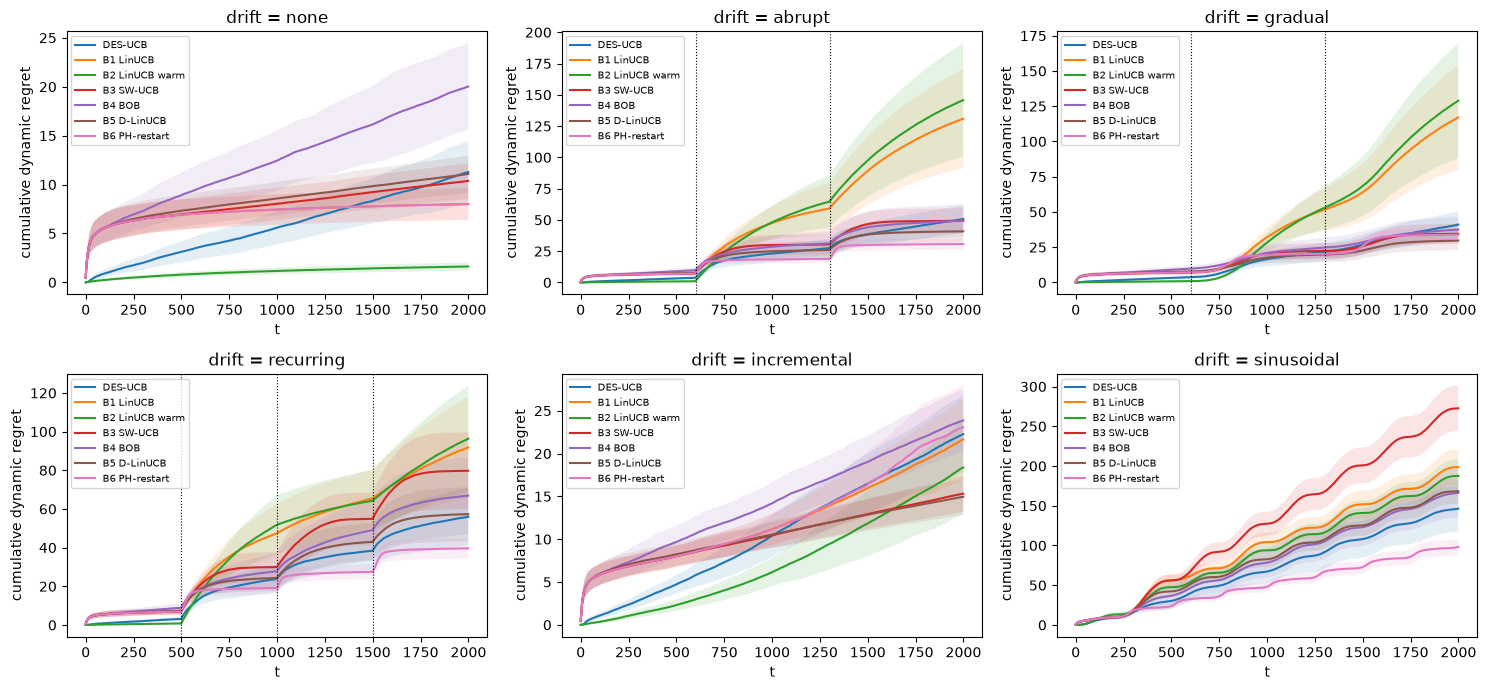

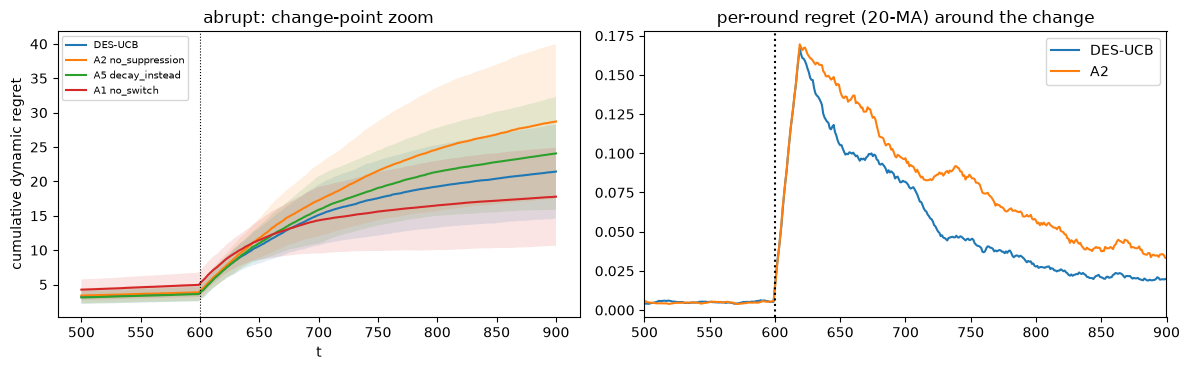

In [14]:
def plot_curves(df, agents, ax, title, zoom=None):
    cur = C.regret_curve(df)
    for a in agents:
        g = cur[cur.agent == a]
        if zoom: g = g[(g.t >= zoom[0]) & (g.t <= zoom[1])]
        ax.plot(g.t, g["mean"], label=C.AGENT_LABELS.get(a, a)); ax.fill_between(g.t, g["mean"] - g["std"], g["mean"] + g["std"], alpha=0.12)
    for cp in sorted(df.loc[df.true_change, "t"].unique()):
        if not zoom or zoom[0] <= cp <= zoom[1]: ax.axvline(cp, color="k", ls=":", lw=0.8)
    ax.set_title(title); ax.set_xlabel("t"); ax.set_ylabel("cumulative dynamic regret"); ax.legend(fontsize=7)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, dt in zip(axes.flat, DRIFTS):
    plot_curves(grid_logs[dt], ["DES-UCB", "B1", "B2", "B3", "B4", "B5", "B6"], ax, f"drift = {dt}")
savefig("regret_curves_grid")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
cp0 = int(sorted(grid_logs["abrupt"].loc[grid_logs["abrupt"].true_change, "t"].unique())[0])
plot_curves(abl_logs["abrupt"], ["DES-UCB", "A2", "A5", "A1"], axes[0], "abrupt: change-point zoom", zoom=(cp0 - 100, cp0 + 300))
pr = abl_logs["abrupt"]; pr = pr[pr.agent.isin(["DES-UCB", "A2"])]
pr_round = pr.groupby(["agent", "t"], observed=True)["regret"].mean().reset_index()
for a in ["DES-UCB", "A2"]:
    g = pr_round[pr_round.agent == a]; axes[1].plot(g.t, pd.Series(g.regret.to_numpy()).rolling(20).mean(), label=a)
axes[1].axvline(cp0, color="k", ls=":"); axes[1].set_xlim(cp0 - 100, cp0 + 300); axes[1].set_title("per-round regret (20-MA) around the change"); axes[1].legend()
savefig("changepoint_zoom")

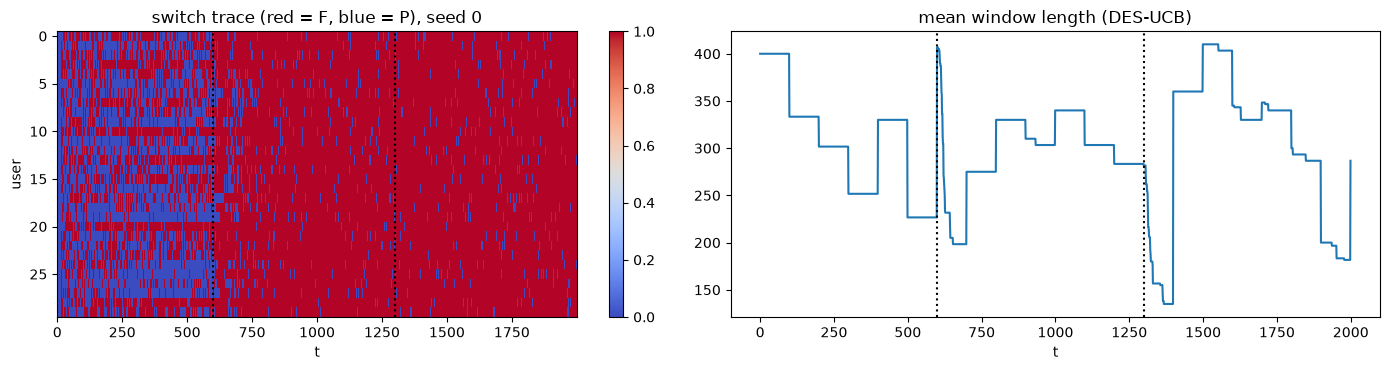

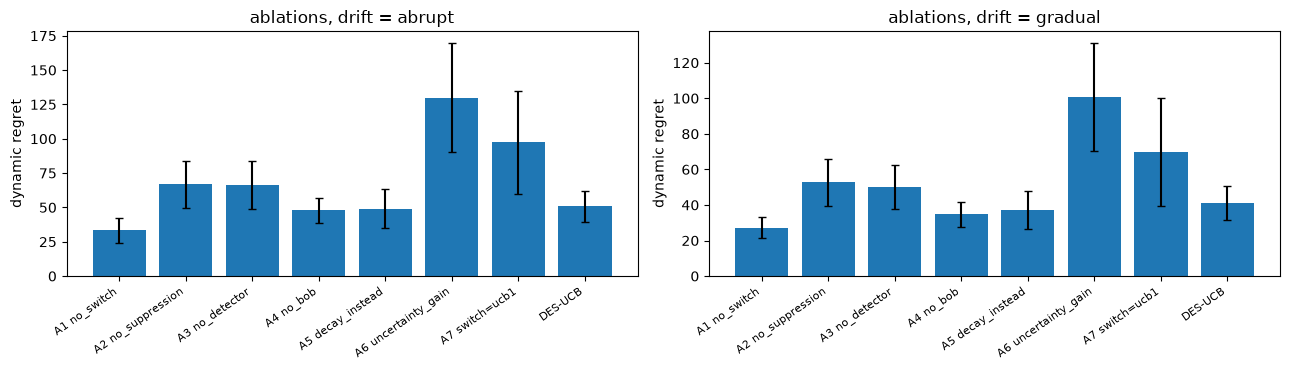

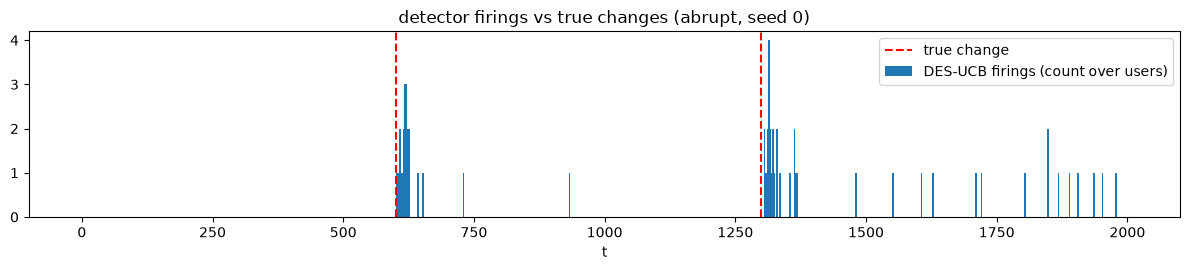

In [15]:
d = abl_logs["abrupt"]; d = d[(d.agent == "DES-UCB") & (d.seed == 0)]
piv = d.pivot_table(index="user", columns="t", values="source", aggfunc=lambda s: (s.astype(str) == "F").mean(), observed=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
im = axes[0].imshow(piv.to_numpy(), aspect="auto", cmap="coolwarm", interpolation="nearest"); axes[0].set_title("switch trace (red = F, blue = P), seed 0")
axes[0].set_xlabel("t"); axes[0].set_ylabel("user"); plt.colorbar(im, ax=axes[0])
for cp in sorted(d.loc[d.true_change, "t"].unique()): axes[0].axvline(cp, color="k", ls=":")
wtraj = d.groupby("t")["window"].mean(); axes[1].plot(wtraj.index, wtraj.values); axes[1].set_title("mean window length (DES-UCB)"); axes[1].set_xlabel("t")
for cp in sorted(d.loc[d.true_change, "t"].unique()): axes[1].axvline(cp, color="k", ls=":")
savefig("switch_trace_window")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for ax, dt in zip(axes, ["abrupt", "gradual"]):
    g = ABL[ABL.drift == dt].set_index("label")
    ax.bar(range(len(g)), g.dyn_regret_mean, yerr=g.dyn_regret_std, capsize=3); ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index, rotation=35, ha="right", fontsize=8)
    ax.set_title(f"ablations, drift = {dt}"); ax.set_ylabel("dynamic regret")
savefig("ablation_bars")

fig, ax = plt.subplots(figsize=(12, 2.8))
f = d.groupby("t")["drift_fired"].sum(); ax.bar(f.index, f.values, width=3, label="DES-UCB firings (count over users)")
for cp in sorted(d.loc[d.true_change, "t"].unique()): ax.axvline(cp, color="r", ls="--", label="true change" if cp == cp0 else None)
ax.legend(); ax.set_title("detector firings vs true changes (abrupt, seed 0)"); ax.set_xlabel("t")
savefig("detector_firings")

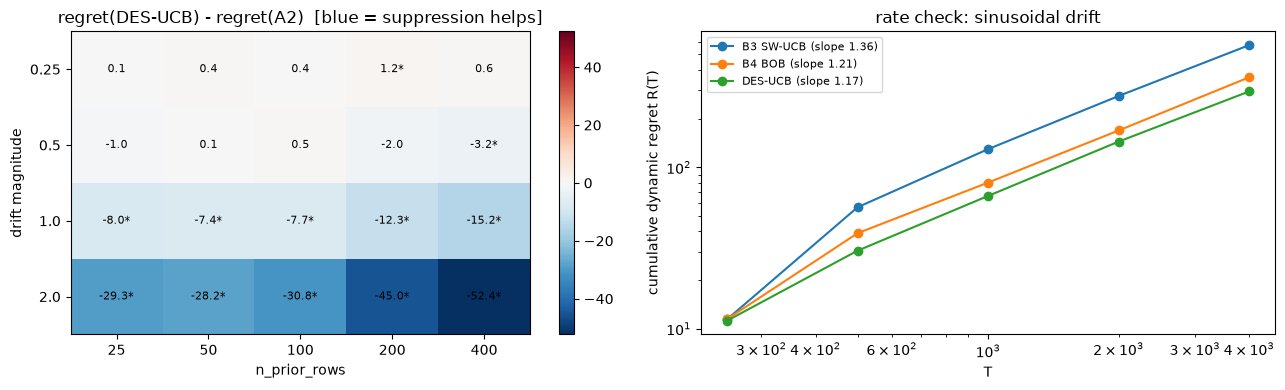

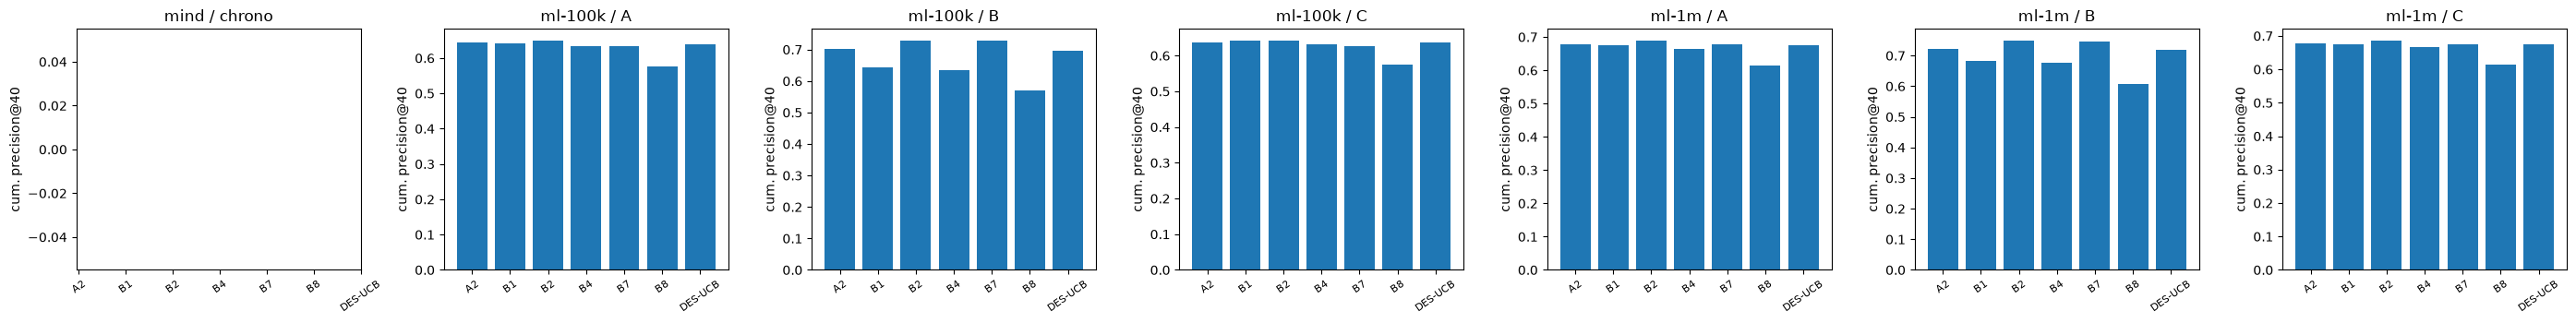

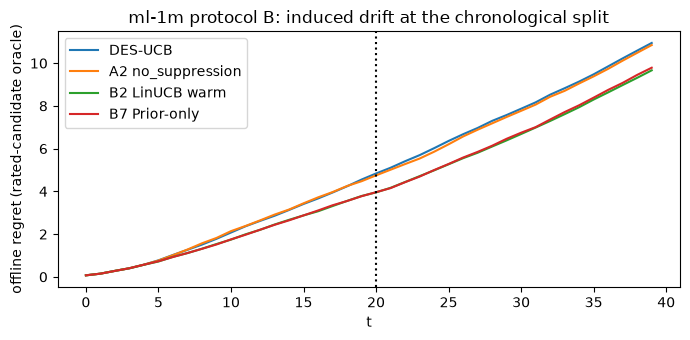

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
im = axes[0].imshow(PHASE.to_numpy(), cmap="RdBu_r", aspect="auto", vmin=-np.nanmax(np.abs(PHASE.to_numpy())), vmax=np.nanmax(np.abs(PHASE.to_numpy())))
axes[0].set_xticks(range(len(PHASE.columns))); axes[0].set_xticklabels(PHASE.columns); axes[0].set_yticks(range(len(PHASE.index))); axes[0].set_yticklabels(PHASE.index)
axes[0].set_xlabel("n_prior_rows"); axes[0].set_ylabel("drift magnitude"); axes[0].set_title("regret(DES-UCB) - regret(A2)  [blue = suppression helps]")
for i in range(PHASE.shape[0]):
    for j in range(PHASE.shape[1]):
        axes[0].text(j, i, f"{PHASE.iloc[i, j]:.1f}{'*' if phase_ci[i, j] else ''}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=axes[0])
for a in RATE_TAB.index:
    R = [RATE_TAB.loc[a, f"R@{T}"] for T in RATE["checkpoints"]]
    axes[1].loglog(RATE["checkpoints"], R, "o-", label=f"{C.AGENT_LABELS.get(a, a)} (slope {RATE_TAB.loc[a, 'slope']:.2f})")
axes[1].set_xlabel("T"); axes[1].set_ylabel("cumulative dynamic regret R(T)"); axes[1].set_title("rate check: sinusoidal drift"); axes[1].legend(fontsize=8)
savefig("phase_and_rate")

if len(REALTAB):
    keys = sorted(set(zip(REALTAB.dataset, REALTAB.protocol)))
    fig, axes = plt.subplots(1, len(keys), figsize=(4 * len(keys), 3.6), squeeze=False)
    for ax, (dsn, pr_) in zip(axes[0], keys):
        g = REALTAB[(REALTAB.dataset == dsn) & (REALTAB.protocol == pr_)].set_index("agent")
        col = [c for c in g.columns if c.startswith("cum_precision@")][-1]
        ax.bar(range(len(g)), g[col]); ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index, rotation=35, fontsize=8)
        ax.set_title(f"{dsn} / {pr_}"); ax.set_ylabel(f"cum. precision@{col.split('@')[1]}")
    savefig("real_precision")
    if ("ml-1m", "B") in real_logs or ("ml-100k", "B") in real_logs:
        key = ("ml-1m", "B") if ("ml-1m", "B") in real_logs else ("ml-100k", "B")
        cur = C.regret_curve(real_logs[key]); fig, ax = plt.subplots(figsize=(7, 3.5))
        for a in ["DES-UCB", "A2", "B2", "B7"]:
            g = cur[cur.agent == a]; ax.plot(g.t, g["mean"], label=C.AGENT_LABELS[a])
        ax.axvline(real_logs[key].loc[real_logs[key].true_change, "t"].min(), color="k", ls=":"); ax.legend()
        ax.set_ylabel("offline regret (rated-candidate oracle)"); ax.set_xlabel("t"); ax.set_title(f"{key[0]} protocol B: induced drift at the chronological split")
        savefig("real_protocolB_offline_regret")

## 13. Claim registry (pre-registered; writes `results/claims.json`)

Each claim is evaluated at the registry size (`experiments.claims`: 5 seeds × 100 users × T = 2000
unless stated) and printed as **SUPPORTED / NOT SUPPORTED** with its numbers. Failures are
reported, not tuned away.

| claim | statement |
|---|---|
| `sanity_oracle` | synthetic oracle ≥ every agent's reward in every round (expected reward vs realised is noisy, so the check is on expected reward: regret ≥ 0 by construction and B9 has the lowest regret) |
| `suppression` | `dyn_regret[DES] < dyn_regret[A2]`, abrupt, `prior_from_pre_drift`, paired 95% CI excludes 0 |
| `suppression_mis` | same under `p_mismatch = 0.2`, `prior_from_pre_drift = false` |
| `stale_ratio` | `stale[DES] < stale[A2]`, paired CI |
| `no_harm` | `dyn_regret[DES] <= 1.10 * dyn_regret[B2]` on `drift = none` |
| `not_redundant` | `dyn_regret[DES] < dyn_regret[A5 decay]`, paired CI |
| `rate` | `slope[DES] <= slope[B4] + 0.05` |
| `real_precision` | `cum_precision@40[DES] >= cum_precision@40[B2]` on ML-1M protocol B |

Then the decision-table verdict is printed.

In [17]:
reg = C.ClaimRegistry(RES / "claims.json")
CL = CFG["experiments"]["claims"]
def claim_run(cfg_name, agents, tag, **over):
    cfg_c = C.load_config(cfg_name, overrides=over)
    df, _ = run_synth(cfg_c, agents, "claims", f"claims_{tag}")
    return df

# sanity_oracle: regret = oracle - E[r] >= 0 every round, and B9 has minimal regret
df_s = claim_run("drift_abrupt", ["DES-UCB", "B9", "B1", "B8"], "sanity", **{})
min_reg = float(df_s.regret.min()); r_s = C.dynamic_regret(df_s)["dynamic_regret_mean"]
reg.assert_claim("sanity_oracle", (min_reg >= -1e-9) and (r_s["B9"] <= r_s.min() + 1e-9),
                 {"min_per_round_regret": min_reg, "regret_B9": r_s["B9"], "regret_min_other": float(r_s.drop("B9").min())},
                 "oracle expected reward >= every agent's expected reward, every round")

# suppression (abrupt, stale prior) + stale_ratio + not_redundant
df_sup = claim_run("drift_abrupt", ["DES-UCB", "A2", "A5", "B4"], "suppression", prior={"prior_from_pre_drift": True, "p_mismatch": 0.0})
pu = C.per_unit(df_sup); pairs = C.summarize_pairs(pu, [("DES-UCB", "A2"), ("DES-UCB", "A5")]).set_index("B")
r_sup = C.dynamic_regret(df_sup)["dynamic_regret_mean"]; det_sup = C.detection_stats(df_sup)
p = pairs.loc["A2"]
reg.assert_claim("suppression", bool(p["mean_diff(A-B)"] < 0 and p["ci_excludes_0"]),
                 {"regret_DES": r_sup["DES-UCB"], "regret_A2": r_sup["A2"], "mean_diff": p["mean_diff(A-B)"], "ci_lo": p["ci_lo"], "ci_hi": p["ci_hi"], "n_units": int(p["n_units"]),
                  "detector_mean_delay": det_sup.loc["DES-UCB", "mean_delay"], "detected_fraction": det_sup.loc["DES-UCB", "detected"] / det_sup.loc["DES-UCB", "n_changes"]},
                 "dyn_regret[DES] < dyn_regret[A2 no_suppression] on abrupt drift with a stale (pre-drift) prior")
spu = C.stale_ratio_per_unit(df_sup); sp = C.summarize_pairs(spu, [("DES-UCB", "A2")]).iloc[0]
reg.assert_claim("stale_ratio", bool(sp["mean_diff(A-B)"] < 0 and sp["ci_excludes_0"]),
                 {"stale_DES": float(spu["DES-UCB"].mean()), "stale_A2": float(spu["A2"].mean()), "mean_diff": sp["mean_diff(A-B)"], "ci_lo": sp["ci_lo"], "ci_hi": sp["ci_hi"]},
                 "post-change rounds conditioned on P: DES < A2")
p5 = pairs.loc["A5"]
reg.assert_claim("not_redundant", bool(p5["mean_diff(A-B)"] < 0 and p5["ci_excludes_0"]),
                 {"regret_DES": r_sup["DES-UCB"], "regret_A5_decay": r_sup["A5"], "mean_diff": p5["mean_diff(A-B)"], "ci_lo": p5["ci_lo"], "ci_hi": p5["ci_hi"]},
                 "purge+reset+burn-in beats passive decay of the prior (A5)")
DES_VS_B4 = float(r_sup["DES-UCB"] / r_sup["B4"])

# suppression_mis
df_mis = claim_run("drift_abrupt", ["DES-UCB", "A2"], "suppression_mis", prior={"prior_from_pre_drift": False, "p_mismatch": 0.2})
pm = C.summarize_pairs(C.per_unit(df_mis), [("DES-UCB", "A2")]).iloc[0]; r_mis = C.dynamic_regret(df_mis)["dynamic_regret_mean"]
reg.assert_claim("suppression_mis", bool(pm["mean_diff(A-B)"] < 0 and pm["ci_excludes_0"]),
                 {"regret_DES": r_mis["DES-UCB"], "regret_A2": r_mis["A2"], "mean_diff": pm["mean_diff(A-B)"], "ci_lo": pm["ci_lo"], "ci_hi": pm["ci_hi"]},
                 "same as `suppression` under p_mismatch=0.2 with a population (not pre-drift) prior")

# no_harm
df_none = claim_run("drift_none", ["DES-UCB", "B2"], "no_harm")
r_none = C.dynamic_regret(df_none)["dynamic_regret_mean"]
reg.assert_claim("no_harm", bool(r_none["DES-UCB"] <= 1.10 * r_none["B2"]),
                 {"regret_DES": r_none["DES-UCB"], "regret_B2": r_none["B2"], "ratio": r_none["DES-UCB"] / r_none["B2"],
                  "F_fraction_DES": float((df_none[df_none.agent == "DES-UCB"].source == "F").mean())},
                 "dyn_regret[DES] <= 1.10 * dyn_regret[B2 warm LinUCB] with no drift")

# rate (from section 11)
reg.assert_claim("rate", bool(RATE_TAB.loc["DES-UCB", "slope"] <= RATE_TAB.loc["B4", "slope"] + 0.05),
                 {"slope_DES": RATE_TAB.loc["DES-UCB", "slope"], "slope_B4": RATE_TAB.loc["B4", "slope"], "checkpoints": RATE["checkpoints"]},
                 "log-log regret slope on sinusoidal drift: DES <= B4 + 0.05")

# real_precision (ML-1M protocol B; falls back to NOT RUN)
if ("ml-1m", "B") in real_logs:
    dfb = real_logs[("ml-1m", "B")]; k = min(40, CFG_ML1M["T"])
    ppu = C.cum_precision_per_unit(dfb, k); pp = C.summarize_pairs(ppu, [("DES-UCB", "B2")]).iloc[0]
    reg.assert_claim("real_precision", bool(ppu["DES-UCB"].mean() >= ppu["B2"].mean()),
                     {"cum_precision@40_DES": float(ppu["DES-UCB"].mean()), "cum_precision@40_B2": float(ppu["B2"].mean()), "mean_diff": pp["mean_diff(A-B)"], "ci_lo": pp["ci_lo"], "ci_hi": pp["ci_hi"], "n_users": int(pp["n_units"])},
                     "ML-1M protocol B: cum_precision@40[DES] >= cum_precision@40[B2]")
else:
    reg.assert_claim("real_precision", None, {"reason": "ML-1M not available in this run"}, "ML-1M protocol B: cum_precision@40[DES] >= cum_precision@40[B2]")
reg.save()

print("\nDECISION TABLE:")
for line in C.decision_table(reg, det_sup.loc["DES-UCB", "mean_delay"], CFG["burn_in_B"], DES_VS_B4, ALL_NOT_ACROSS_MAGNITUDES):
    print("  ->", line)

claims_sanity:   0%|          | 0/500 [00:00<?, ?it/s]

[SUPPORTED] sanity_oracle: oracle expected reward >= every agent's expected reward, every round
    min_per_round_regret = 0.0
    regret_B9 = 0.0
    regret_min_other = 50.439051811528095


claims_suppression:   0%|          | 0/500 [00:00<?, ?it/s]

[SUPPORTED] suppression: dyn_regret[DES] < dyn_regret[A2 no_suppression] on abrupt drift with a stale (pre-drift) prior
    regret_DES = 50.439051811528095
    regret_A2 = 65.1170376451258
    mean_diff = -14.6779858335977
    ci_lo = -15.9526083290919
    ci_hi = -13.433141308625371
    n_units = 500
    detector_mean_delay = 23.32364729458918
    detected_fraction = 0.998


[SUPPORTED] stale_ratio: post-change rounds conditioned on P: DES < A2
    stale_DES = 0.07039857142857144
    stale_A2 = 0.09871428571428573
    mean_diff = -0.028315714285714284
    ci_lo = -0.032483
    ci_hi = -0.02455442857142858
[NOT SUPPORTED] not_redundant: purge+reset+burn-in beats passive decay of the prior (A5)
    regret_DES = 50.439051811528095
    regret_A5_decay = 47.26324972098633
    mean_diff = 3.1758020905417808
    ci_lo = 1.9037842333170338
    ci_hi = 4.353234215681397


claims_suppression_mis:   0%|          | 0/500 [00:00<?, ?it/s]

[SUPPORTED] suppression_mis: same as `suppression` under p_mismatch=0.2 with a population (not pre-drift) prior
    regret_DES = 78.56122406533756
    regret_A2 = 93.29514954581703
    mean_diff = -14.733925480479392
    ci_lo = -16.023681585816718
    ci_hi = -13.448556934263268


claims_no_harm:   0%|          | 0/500 [00:00<?, ?it/s]

[NOT SUPPORTED] no_harm: dyn_regret[DES] <= 1.10 * dyn_regret[B2 warm LinUCB] with no drift
    regret_DES = 11.136651022067612
    regret_B2 = 1.6224510803333223
    ratio = 6.864090484490699
    F_fraction_DES = 0.516145
[SUPPORTED] rate: log-log regret slope on sinusoidal drift: DES <= B4 + 0.05
    slope_DES = 1.1680587954526207
    slope_B4 = 1.2066781612762816
    checkpoints = [250, 500, 1000, 2000, 4000]
[NOT SUPPORTED] real_precision: ML-1M protocol B: cum_precision@40[DES] >= cum_precision@40[B2]
    cum_precision@40_DES = 0.7194915254237289
    cum_precision@40_B2 = 0.7496610169491524
    mean_diff = -0.030169491525423725
    ci_lo = -0.03517161016949153
    ci_hi = -0.024913135593220347
    n_users = 295

DECISION TABLE:
  -> NO DECISION-TABLE BRANCH TRIGGERED (claims consistent with the title as stated)


## 14. Paper-text gate

Reads `results/claims.json` and writes `results/results_skeleton.md`: one bullet per SUPPORTED
claim with its numbers, and a "Not supported / do not write" list. The results section of the
paper may only be written from that file.

In [18]:
claims = json.loads((RES / "claims.json").read_text())
lines = ["# Results skeleton (auto-generated from results/claims.json)", "",
         "Only the bullets under *Supported* may appear as findings in the paper.", "", "## Supported"]
sup = [c for c in claims.values() if c["verdict"] == "SUPPORTED"]
lines += [f"- **{c['claim']}** — {c['description']}. Numbers: " + ", ".join(f"{k}={v:.4g}" if isinstance(v, float) else f"{k}={v}" for k, v in c["stats"].items()) for c in sup] or ["- (none)"]
lines += ["", "## Not supported / do not write"]
lines += [f"- **{c['claim']}** [{c['verdict']}] — {c['description']}. Numbers: " + ", ".join(f"{k}={v:.4g}" if isinstance(v, float) else f"{k}={v}" for k, v in c["stats"].items())
          for c in claims.values() if c["verdict"] != "SUPPORTED"] or ["- (none)"]
lines += ["", "## Decision table", *[f"- {l}" for l in C.decision_table(reg, det_sup.loc['DES-UCB', 'mean_delay'], CFG['burn_in_B'], DES_VS_B4, ALL_NOT_ACROSS_MAGNITUDES)]]
(RES / "results_skeleton.md").write_text("\n".join(lines))
print("\n".join(lines))
print(f"\nTotal notebook wall time so far: {(time.time() - T_START) / 60:.1f} min")

# Results skeleton (auto-generated from results/claims.json)

Only the bullets under *Supported* may appear as findings in the paper.

## Supported
- **sanity_oracle** — oracle expected reward >= every agent's expected reward, every round. Numbers: min_per_round_regret=0, regret_B9=0, regret_min_other=50.44
- **suppression** — dyn_regret[DES] < dyn_regret[A2 no_suppression] on abrupt drift with a stale (pre-drift) prior. Numbers: regret_DES=50.44, regret_A2=65.12, mean_diff=-14.68, ci_lo=-15.95, ci_hi=-13.43, n_units=500, detector_mean_delay=23.32, detected_fraction=0.998
- **stale_ratio** — post-change rounds conditioned on P: DES < A2. Numbers: stale_DES=0.0704, stale_A2=0.09871, mean_diff=-0.02832, ci_lo=-0.03248, ci_hi=-0.02455
- **suppression_mis** — same as `suppression` under p_mismatch=0.2 with a population (not pre-drift) prior. Numbers: regret_DES=78.56, regret_A2=93.3, mean_diff=-14.73, ci_lo=-16.02, ci_hi=-13.45
- **rate** — log-log regret slope on sinusoidal drift: DES <= 

## 15. README

### How to run
```bash
python3.11 -m venv .venv && . .venv/bin/activate
pip install -r requirements.txt
pytest -q                                   # unit tests for des_ucb_core.py
jupyter nbconvert --to notebook --execute DES_UCB.ipynb --output DES_UCB.ipynb --ExecutePreprocessor.timeout=3600
```
Configuration: `configs/default.yaml` (+ `configs/drift_*.yaml`, `configs/<dataset>.yaml`, deep-merged
via `C.load_config`). Experiment sizes live under `experiments:` in `default.yaml`. Runtime data is
downloaded to `data/` (git-ignored); everything produced lands in `results/` (parquet, csv, png,
`claims.json`, `results_skeleton.md`). Optional datasets are enabled through `datasets:`
(Yahoo R6 / KuaiRand / Netflix need a local path).

### Metric glossary
* **dynamic regret** (synthetic only): `Σ_t max_a x_a^T theta_t − x_{a_t}^T theta_t` against the
  hidden, time-varying oracle. Requires knowing `theta_t`, so it exists only in simulation.
* **offline regret** (rated-item datasets): `Σ_t max_{a ∈ rated candidates} r_a − r_{a_t}`; the
  "oracle" is the best *available* logged reward, the candidate set is restricted to items the user
  rated, and the estimate is biased by the logging process. It is *not* dynamic regret and is never
  called that.
* **replay reward** (uniform-random logging slices, R6/KuaiRand): mean logged reward over rounds
  where the agent's action equals the logged action — the only real-data metric here that is an
  unbiased estimate of on-policy reward.
* **cum. precision@k / recall@T**: hits (rating ≥ 4 or click) in the first k rounds / k, and hits
  over T divided by the user's number of relevant items.
* **stale evidence ratio**: fraction of post-change rounds on which the agent conditioned on P.

### Design decisions
1. `lam_threshold` retuned 50 → 1.0 after the pilot's "DETECTION FAILURE" branch (section 6); the
   PH statistic is the squared residual of the active source, whose scale is `sigma_reward^2 ≈ 0.01`.
2. Generalisation gain is the *relative* squared-error reduction `(e_other − e_active)/(e_other + e_active)`
   (scale-free in `[-1, 1]`), then rescaled to `[0,1]` for EXP3 with importance weighting.
3. F is not offered to the switch until it holds `min(d, w_min)` live rows (rank-deficient ridge);
   those rounds are forced to P and not credited. During the forced burn-in F is used regardless.
4. Suppression halves the *current* window (`max(w_min, w//2)`), purges older rows, resets P's EXP3
   weight to the F weight (so P starts from "no better than F"), and forces F for `B` rounds.
5. B5 discount `0.995`, B3 fixed window `400`, B6 restarts a warm LinUCB from `D_prior` on each
   PH firing (same detector settings as DES-UCB).
6. Real data: user-disjoint 85/5/10 split; SVD item factors fit on train users only and frozen;
   demographic cohorts (`gender|age`) for ML priors; MIND cohorts = dominant clicked category
   (no demographics available); MIND from the Hugging Face mirror because the official blob is closed.
7. Every agent of a (seed, user) job sees the identical environment (pre-drawn noise, `env.reset()`),
   so all CIs are paired; agent RNGs are seeded from `(seed, crc32(agent name))`.
8. Exploratory grids (sections 7–9, 11) are run at reduced size to fit the 30-minute budget; the
   claim registry (section 13) re-runs its cells at 5 seeds × 100 users × T = 2000.
9. `tests/test_core.py::test_des_within_10pct_of_warm_linucb_on_no_drift` is a strict `xfail`
   mirroring the `no_harm` claim; if `no_harm` ever becomes SUPPORTED the strict xfail will fail and
   the marker must be removed.

All numbers, tables and figures above were produced by executing this notebook; none were pre-filled.